# Entropy Statistics - First N Tokens (English)

This notebook collects entropy values using only the first N tokens (N=5) from responses.

## Goals:
1. Use same dataset as full_token analysis for consistency
2. Call API 1 time per query (n=1) to save tokens
3. Calculate entropy from first 5 tokens only
4. Compare results with full_token method


## Cell 1: Setup and Import


In [5]:
import sys
import os
import json
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# Add current directory to path for local module
current_dir = Path().absolute()
sys.path.insert(0, str(current_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from typing import List, Dict

# Set matplotlib to handle fonts
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Import custom entropy calculation module (from current directory)
from entropy_first_n_token import calculate_entropy_from_response

print("Setup completed!")


Setup completed!


## Cell 2: Import Modules and Load Queries


In [6]:
from backend.models.adaptive_controller import AdaptiveController
from backend.config.config import get_config

# Initialize adaptive controller
config = get_config()
controller = AdaptiveController(
    k_min=config.adaptive.k_min,
    k_max=config.adaptive.k_max
)

# Load test queries from JSON (same dataset as full_token analysis)
queries_file = Path("test_queries_en.json")
with open(queries_file, 'r', encoding='utf-8') as f:
    test_queries = json.load(f)

# Flatten queries into list with categories
all_queries = []
for category, queries in test_queries.items():
    for query in queries:
        all_queries.append({
            'query': query,
            'difficulty': category
        })

print(f"Loaded {len(all_queries)} queries")
print(f"  - Easy: {len([q for q in all_queries if q['difficulty'] == 'easy'])}")
print(f"  - Medium: {len([q for q in all_queries if q['difficulty'] == 'medium'])}")
print(f"  - Hard: {len([q for q in all_queries if q['difficulty'] == 'hard'])}")
print(f"\nUsing n_iterations = 1 to save tokens")
print(f"Using first N = 5 tokens for entropy calculation")


Loaded 101 queries
  - Easy: 34
  - Medium: 34
  - Hard: 33

Using n_iterations = 5 for better averaging
Using first N = 5 tokens for entropy calculation


## Cell 3: Collect Entropy Data (n=1, first 5 tokens)


In [8]:
from backend.services.llm_service import generate_with_logprobs
from backend.models.adaptive_controller import _build_style_prompt

def collect_entropy_data_first_n(
    queries: List[Dict], 
    language: str = "en", 
    n_iterations: int = 1,
    num_tokens: int = 5
) -> pd.DataFrame:
    """
    Collect entropy values from queries using first N tokens.
    Call API n_iterations times (default 1 to save tokens).
    
    Returns:
        DataFrame with columns: sample_id, query, difficulty, entropy (first N tokens)
    """
    results = []
    
    print(f"Starting entropy collection with n_iterations={n_iterations}, first {num_tokens} tokens...")
    print(f"Total queries: {len(queries)}\n")
    
    for idx, item in enumerate(queries, 1):
        query = item['query']
        difficulty = item['difficulty']
        
        print(f"[{idx}/{len(queries)}] {difficulty}: {query[:60]}...")
        
        try:
            # Call API n_iterations times
            entropies_per_iteration = []
            
            for iteration in range(n_iterations):
                # Use different styles for each iteration (cycle through)
                style = config.adaptive.style_candidates[iteration % len(config.adaptive.style_candidates)]
                style_prompt = _build_style_prompt(query, style, language)
                
                # Call API directly to get logprobs
                # Optimize: only generate num_tokens to save API calls
                gen_result = generate_with_logprobs(
                    query=query,
                    style_prompt=style_prompt,
                    language=language,
                    model=config.adaptive.phase1_model,
                    temperature=config.adaptive.phase1_temperature,
                    max_tokens=num_tokens  # Only generate the tokens we need
                )
                
                logprobs = gen_result.get("logprobs", [])
                if logprobs:
                    # Calculate entropy from first N tokens
                    entropy = calculate_entropy_from_response(logprobs, num_tokens=num_tokens)
                    entropies_per_iteration.append(entropy)
            
            # Get entropy (single value when n_iterations=1, or average if >1)
            avg_entropy = sum(entropies_per_iteration) / len(entropies_per_iteration) if entropies_per_iteration else 0.0
            
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': avg_entropy,
                'entropy_std': np.std(entropies_per_iteration) if len(entropies_per_iteration) > 1 else 0.0,
                'n_iterations': n_iterations,
                'num_tokens': num_tokens
            })
            
        except Exception as e:
            print(f"    ERROR: {str(e)}")
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': None,
                'entropy_std': None,
                'error': str(e),
                'n_iterations': n_iterations,
                'num_tokens': num_tokens
            })
            continue
    
    return pd.DataFrame(results)

# Collect data with n=1, first 5 tokens (to save tokens)
df_entropy = collect_entropy_data_first_n(all_queries, language="en", n_iterations=1, num_tokens=5)

print(f"\n✓ Collected {len(df_entropy)} samples")
df_entropy.head(10)


Starting entropy collection with n_iterations=1, first 5 tokens...
Total queries: 101

[1/101] easy: what is python?...
[2/101] easy: what is git?...
[3/101] easy: what is ai?...
[4/101] easy: what is machine learning?...
[5/101] easy: what is deep learning?...
[6/101] easy: what is neural network?...
[7/101] easy: what is a database?...
[8/101] easy: what is an algorithm?...
[9/101] easy: what is programming?...
[10/101] easy: what is software?...
[11/101] easy: what is java?...
[12/101] easy: what is javascript?...
[13/101] easy: what is html?...
[14/101] easy: what is css?...
[15/101] easy: what is sql?...
[16/101] easy: what is api?...
[17/101] easy: what is json?...
[18/101] easy: what is xml?...
[19/101] easy: what is http?...
[20/101] easy: what is https?...
[21/101] easy: what is tcp?...
[22/101] easy: what is ip?...
[23/101] easy: what is dns?...
[24/101] easy: what is cloud?...
[25/101] easy: what is docker?...
[26/101] easy: what is kubernetes?...
[27/101] easy: what is linu

,sample_id,query,difficulty,entropy,entropy_std,n_iterations,num_tokens
0,1,what is python?,easy,0.000176,0.0,1,5
1,2,what is git?,easy,0.000753,0.0,1,5
2,3,what is ai?,easy,0.168702,0.0,1,5
3,4,what is machine learning?,easy,0.185764,0.0,1,5
4,5,what is deep learning?,easy,0.002023,0.0,1,5
5,6,what is neural network?,easy,0.000003,0.0,1,5
6,7,what is a database?,easy,0.015836,0.0,1,5
7,8,what is an algorithm?,easy,0.018609,0.0,1,5
8,9,what is programming?,easy,0.000010,0.0,1,5
9,10,what is software?,easy,0.074030,0.0,1,5


## Cell 4: Save Results to CSV


In [9]:
# Save results to CSV
csv_file = "entropy_analysis_results_en.csv"
df_entropy.to_csv(csv_file, index=False)
print(f"✓ Results saved to: {csv_file}")
print(f"Total samples: {len(df_entropy)}")
df_entropy.head(10)


✓ Results saved to: entropy_analysis_results_en.csv
Total samples: 101


,sample_id,query,difficulty,entropy,entropy_std,n_iterations,num_tokens
0,1,what is python?,easy,0.000176,0.0,1,5
1,2,what is git?,easy,0.000753,0.0,1,5
2,3,what is ai?,easy,0.168702,0.0,1,5
3,4,what is machine learning?,easy,0.185764,0.0,1,5
4,5,what is deep learning?,easy,0.002023,0.0,1,5
5,6,what is neural network?,easy,0.000003,0.0,1,5
6,7,what is a database?,easy,0.015836,0.0,1,5
7,8,what is an algorithm?,easy,0.018609,0.0,1,5
8,9,what is programming?,easy,0.000010,0.0,1,5
9,10,what is software?,easy,0.074030,0.0,1,5


## Cell 5: Read Result

**Note:** If you have already run the data collection (Cell 3) and saved results, you can skip Cells 1-4 and start from this cell to load the saved results.


In [10]:
# Read results from CSV file
csv_file = "entropy_analysis_results_en.csv"
df_entropy = pd.read_csv(csv_file)

print(f"✓ Loaded {len(df_entropy)} samples from {csv_file}")
print(f"\nData preview:")
df_entropy.head(10)


✓ Loaded 101 samples from entropy_analysis_results_en.csv

Data preview:


,sample_id,query,difficulty,entropy,entropy_std,n_iterations,num_tokens
0,1,what is python?,easy,0.000176,0.0,1,5
1,2,what is git?,easy,0.000753,0.0,1,5
2,3,what is ai?,easy,0.168702,0.0,1,5
3,4,what is machine learning?,easy,0.185764,0.0,1,5
4,5,what is deep learning?,easy,0.002023,0.0,1,5
5,6,what is neural network?,easy,0.000003,0.0,1,5
6,7,what is a database?,easy,0.015836,0.0,1,5
7,8,what is an algorithm?,easy,0.018609,0.0,1,5
8,9,what is programming?,easy,0.000010,0.0,1,5
9,10,what is software?,easy,0.074030,0.0,1,5


## Cell 6: Basic Statistics


In [11]:
# Filter valid samples
df_valid = df_entropy[df_entropy['entropy'].notna()]

print("=== BASIC STATISTICS (First 5 Tokens) ===\n")
print("Overall Statistics:")
print(df_valid['entropy'].describe())
print(f"\nRange: [{df_valid['entropy'].min():.4f}, {df_valid['entropy'].max():.4f}]")

print("\nBy Difficulty Level:")
print(df_valid.groupby('difficulty')['entropy'].describe())

print("\nPercentiles:")
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(df_valid['entropy'], p)
    print(f"  {p}th percentile: {val:.4f}")


=== BASIC STATISTICS (First 5 Tokens) ===

Overall Statistics:
count    101.000000
mean       0.133868
std        0.130722
min        0.000001
25%        0.028258
50%        0.107409
75%        0.201185
max        0.579578
Name: entropy, dtype: float64

Range: [0.0000, 0.5796]

By Difficulty Level:
            count      mean       std       min       25%       50%       75%  \
difficulty                                                                      
easy         34.0  0.095853  0.108782  0.000003  0.016529  0.060370  0.158859   
hard         33.0  0.199064  0.141244  0.011011  0.073508  0.184856  0.306771   
medium       34.0  0.108606  0.119193  0.000001  0.011068  0.085200  0.158009   

                 max  
difficulty            
easy        0.533304  
hard        0.579578  
medium      0.525763  

Percentiles:
  5th percentile: 0.0003
  10th percentile: 0.0012
  25th percentile: 0.0283
  50th percentile: 0.1074
  75th percentile: 0.2012
  90th percentile: 0.3200
  95th per

## Cell 7: Scatter Plot Visualization


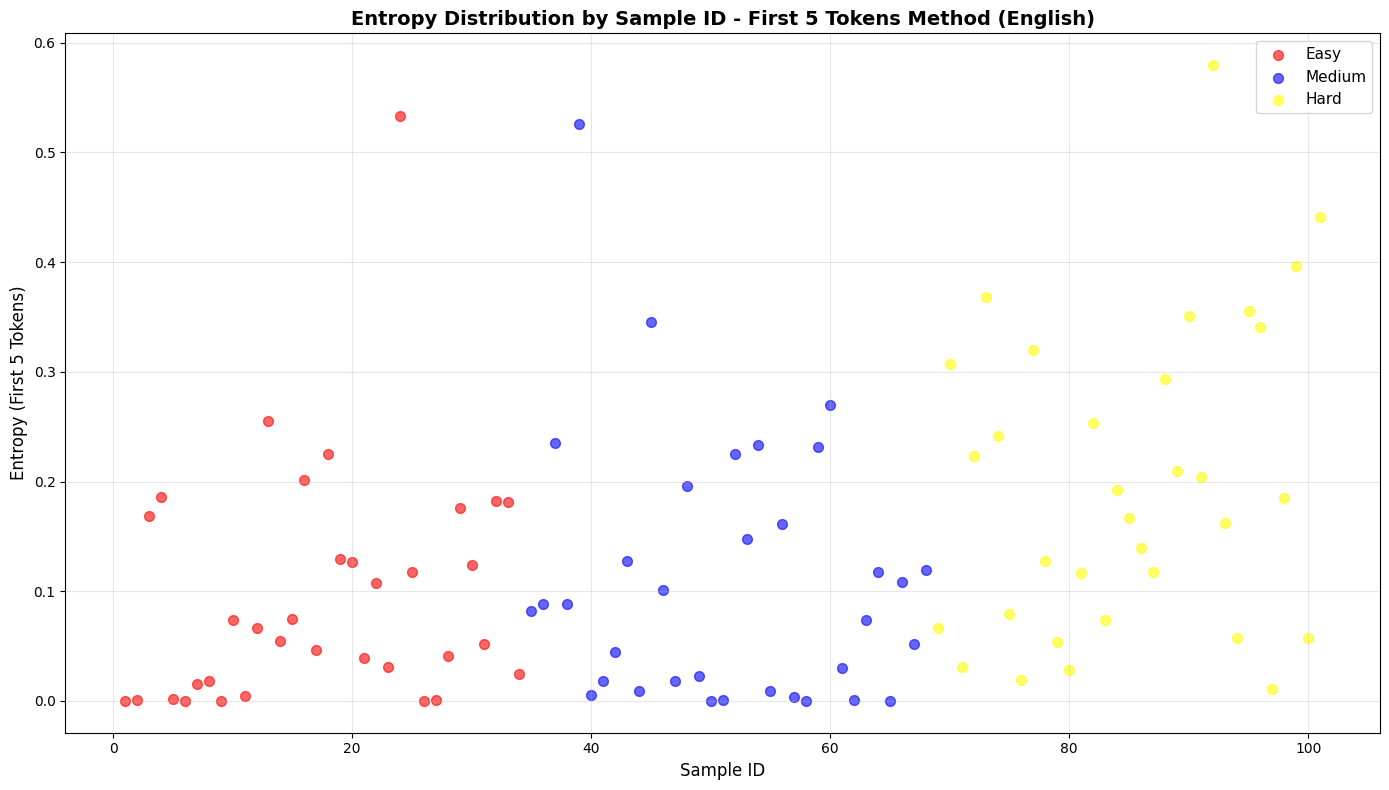

✓ Visualization completed
  - Red: Easy queries (34 samples)
  - Blue: Medium queries (34 samples)
  - Yellow: Hard queries (33 samples)


In [12]:
# Filter valid samples
df_valid = df_entropy[df_entropy['entropy'].notna()]

# Color mapping: Red (easy), Blue (medium), Yellow (hard)
color_map = {
    'easy': 'red',
    'medium': 'blue',
    'hard': 'yellow'
}

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

for difficulty in ['easy', 'medium', 'hard']:
    df_diff = df_valid[df_valid['difficulty'] == difficulty]
    if len(df_diff) > 0:
        ax.scatter(
            df_diff['sample_id'],
            df_diff['entropy'],
            c=color_map[difficulty],
            label=difficulty.capitalize(),
            alpha=0.6,
            s=50
        )

ax.set_xlabel('Sample ID', fontsize=12)
ax.set_ylabel('Entropy (First 5 Tokens)', fontsize=12)
ax.set_title('Entropy Distribution by Sample ID - First 5 Tokens Method (English)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization completed")
print(f"  - Red: Easy queries ({len(df_valid[df_valid['difficulty'] == 'easy'])} samples)")
print(f"  - Blue: Medium queries ({len(df_valid[df_valid['difficulty'] == 'medium'])} samples)")
print(f"  - Yellow: Hard queries ({len(df_valid[df_valid['difficulty'] == 'hard'])} samples)")
